In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
#PARAMETROS
muy = 0
muz = 0
PY=[0,0]
PZ=[0,0]
vizY = [0,4]
hy = [0,1.2/vizY[1]]
vizZ = [0,4]
hz = [0,1.0/vizZ[1]]
vizX = 4
hx = 0.5
dz = 0.2
dy = 0.15

In [3]:
def P0Xcm(P0,PX):
    return P0*(1-(1-hx*PX)**vizX)

def PXYcm(PX,PY):
    return PX*(1-(1-hy[1]*PY[1])**(vizY[1]-vizY[0])*(1-hy[1]*PY[1]-hy[0]*PY[0])**vizY[0])

def PXY1cm(PX,PY):
    return PX*(1-(1-hy[0])**(vizY[1]-vizY[0])*(1-hy[1])**vizY[1])/(2-(1-hy[0])**vizY[0]-(1-hy[1])**vizY[1]) * (muy/2*(1-(1-PY[1]*hy[1])**vizY[1])+(1-muy/2)*(1-(1-PY[0]*hy[0])**vizY[0]))

def PXY2cm(PX,PY):
    return PX*(1-(1-hy[0])**(vizY[1]-vizY[0])*(1-hy[1])**vizY[1])/(2-(1-hy[0])**vizY[0]-(1-hy[1])**vizY[1]) * (muy/2*(1-(1-PY[0]*hy[0])**vizY[0])+(1-muy/2)*(1-(1-PY[1]*hy[1])**vizY[1]))

def PY1Zcm(PY,PZ):
    return PY[0]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PZ[1]-hz[0]*PZ[0])**vizZ[0])
    
def PY2Zcm(PY,PZ):
    return PY[1]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PZ[1]-hz[0]*PZ[0])**vizZ[0])

def PY1Z1cm(PY,PZ):
    return PY[0]*(1-(1-hz[0])**(vizZ[1]-vizZ[0])*(1-hz[1])**vizZ[1])/(2-(1-hz[0])**vizZ[0]-(1-hz[1])**vizZ[1]) * (muz/2*(1-(1-hz[1]*PZ[1])**vizZ[1])+(1-muz/2)*(1-(1-hz[0]*PZ[0])**vizZ[0]))
    
def PY2Z1cm(PY,PZ):
    return PY[1]*(1-(1-hz[0])**(vizZ[1]-vizZ[0])*(1-hz[1])**vizZ[1])/(2-(1-hz[0])**vizZ[0]-(1-hz[1])**vizZ[1]) * (muz/2*(1-(1-hz[1]*PZ[1])**vizZ[1])+(1-muz/2)*(1-(1-hz[0]*PZ[0])**vizZ[0]))

def PY1Z2cm(PY,PZ):
    return PY[0]*(1-(1-hz[0])**(vizZ[1]-vizZ[0])*(1-hz[1])**vizZ[1])/(2-(1-hz[0])**vizZ[0]-(1-hz[1])**vizZ[1]) * (muz/2*(1-(1-hz[0]*PZ[0])**vizZ[0])+(1-muz/2)*(1-(1-hz[1]*PZ[1])**vizZ[1]))

def PY2Z2cm(PY,PZ):
    return PY[1]*(1-(1-hz[0])**(vizZ[1]-vizZ[0])*(1-hz[1])**vizZ[1])/(2-(1-hz[0])**vizZ[0]-(1-hz[1])**vizZ[1]) * (muz/2*(1-(1-hz[0]*PZ[0])**vizZ[0])+(1-muz/2)*(1-(1-hz[1]*PZ[1])**vizZ[1]))

In [4]:
#revisado
def PX0par(P0,PX0):
    return P0*(1-(1-hx*PX0/P0)**vizX)
#revisado
def pX0par2(P0,PX0):
    return (1-(1-hx*PX0/P0)**(vizX-1))

#############################################
#revisado
def PXYpar(PX,PXY1,PXY2):
    return PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])
#revisado
def PXYpar2(PX,PXY1,PXY2):
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))

#############################################
#revisado
def PXY1par(PX,PXY1,PXY2):
    return PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])/((1-(1-PXY1/PX)**vizY[0])
            +(1-(1-PXY2/PX)**vizY[1]))*(muy/2*(1-(1-PXY2/PX)**vizY[1])+(1-muy/2)*(1-(1-PXY1/PX)**vizY[0]))
#revisado
def PXY1par2(PX,PXY1,PXY2): 
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))/((1-(1-PXY1/PX)**(vizY[0]-1))
            +(1-(1-PXY2/PX)**(vizY[1]-1)))*(muy/2*(1-(1-PXY2/PX)**(vizY[1]-1))+(1-muy/2)*(1-(1-PXY1/PX)**(vizY[0]-1)))

#############################################
#revisado
def PXY2par(PX,PXY1,PXY2): 
    return (PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])/((1-(1-PXY1/PX)**vizY[0])+(1-(1-PXY2/PX)**vizY[1]))
            *(muy/2*(1-(1-PXY1/PX)**vizY[0])+(1-muy/2)*(1-(1-PXY2/PX)**vizY[1])))
#revisado
def PXY2par2(PX,PXY1,PXY2):
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))/((1-(1-PXY1/PX)**(vizY[0]-1))
            +(1-(1-PXY2/PX)**(vizY[1]-1)))*(muy/2*(1-(1-PXY1/PX)**(vizY[0]-1))+(1-muy/2)*(1-(1-PXY2/PX)**(vizY[1]-1)))

#############################################
# revisado
def PY1Zpar(PY,PY1Z1,PY1Z2):
    return PY[0]*(1-(1-hz[1]*PY1Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[1]-hz[0]*PY1Z1/PY[1])**vizZ[0])
#revisado
def PY1Zpar2(PY,PY1Z1,PY1Z2):
    return (1-(1-hz[1]*PY1Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[1]-hz[0]*PY1Z1/PY[1])**(vizZ[0]-1))

#############################################
#revisado
def PY2Zpar(PY,PY2Z1,PY2Z2):
    return PY[1]*(1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**vizZ[0])
#revisado
def PY2Zpar2(PY,PY2Z1,PY2Z2):
    return (1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**(vizZ[0]-1))

#############################################
def PY1Z1par(PY,PY1Z1,PY1Z2):
    return (PY[0]*(1-(1-hz[1]*PY1Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[1]-hz[0]*PY1Z1/PY[1])**vizZ[0])/((1-(1-PY1Z1/PY[1])**vizZ[0]+(1-(1-PY1Z2/PY[1])**vizZ[1])))
        * (muz/2*(1-(1-PY1Z2/PY[1])**vizZ[1])+(1-muz/2)*(1-(1-PY1Z1/PY[1])**vizZ[0])))

def PY1Z1par2(PY,PY1Z1,PY1Z2):
    return ((1-(1-hz[1]*PY1Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[1]-hz[0]*PY1Z1/PY[1])**(vizZ[0]-1))/((1-(1-PY1Z1/PY[1])**(vizZ[0]-1)+(1-(1-PY1Z2/PY[1])**(vizZ[1]-1))))
        * (muz/2*(1-(1-PY1Z2/PY[1])**(vizZ[1]-1))+(1-muz/2)*(1-(1-PY1Z1/PY[1])**(vizZ[0]-1))))

#############################################
def PY1Z2par(PY,PY1Z1,PY1Z2):
    return 0#(PY[0]*(1-(1-hz[1]*PY1Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[1]-hz[0]*PY1Z1/PY[1])**vizZ[0])/((1-(1-PY1Z1/PY[1])**vizZ[0]+(1-(1-PY1Z2/PY[1])**vizZ[1])))
        #* (muz/2*(1-(1-PY1Z1/PY[1])**vizZ[0])+(1-muz/2)*(1-(1-PY1Z2/PY[1])**vizZ[1])))

def PY1Z2par2(PY,PY1Z1,PY1Z2):
    return 0#((1-(1-hz[1]*PY1Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[1]-hz[0]*PY1Z1/PY[1])**(vizZ[0]-1))/((1-(1-PY1Z1/PY[1])**(vizZ[0]-1)+(1-(1-PY1Z2/PY[1])**(vizZ[1]-1))))
        #* (muz/2*(1-(1-PY1Z1/PY[1])**(vizZ[0]-1))+(1-muz/2)*(1-(1-PY1Z2/PY[1])**(vizZ[1]-1))))

#############################################
def PY2Z1par(PY,PY2Z1,PY2Z2):
    return (PY[1]*(1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**vizZ[0])/((1-(1-PY2Z1/PY[1])**vizZ[0]+(1-(1-PY2Z2/PY[1])**vizZ[1])))
        * (muz/2*(1-(1-PY2Z2/PY[1])**vizZ[1])+(1-muz/2)*(1-(1-PY2Z1/PY[1])**vizZ[0])))

def PY2Z1par2(PY,PY2Z1,PY2Z2):
    return ((1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**(vizZ[0]-1))/((1-(1-PY2Z1/PY[1])**(vizZ[0]-1)+(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))))
            * (muz/2*(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))+(1-muz/2)*(1-(1-PY2Z1/PY[1])**(vizZ[0]-1))))

#############################################
def PY2Z2par(PY,PY2Z1,PY2Z2):
    return (PY[1]*(1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**vizZ[0])/((1-(1-PY2Z1/PY[1])**vizZ[0]+(1-(1-PY2Z2/PY[1])**vizZ[1])))
        * (muz/2*(1-(1-PY2Z1/PY[1])**vizZ[0])+(1-muz/2)*(1-(1-PY2Z2/PY[1])**vizZ[1])))

def PY2Z2par2(PY,PY2Z1,PY2Z2):
    return ((1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**(vizZ[0]-1))/((1-(1-PY2Z1/PY[1])**(vizZ[0]-1)+(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))))
        * (muz/2*(1-(1-PY2Z1/PY[1])**(vizZ[0]-1))+(1-muz/2)*(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))))

In [5]:
def Dinamica_cm(t):
    global PX, PY, PZ, P0
    PX = 0.3
    PY[0] = 0
    PY[1] = 0.15
    PZ[0] = 0
    PZ[1] = 0.1
    P0 = 1-PX-PY[0]-PY[1]-PZ[0]-PZ[1]
    for i in range(t):
        new_PX = PX + P0Xcm(P0, PX) - PXY1cm(PX, PY) - PXY2cm(PX,PY)
        new_PY1 = 0#PY[0] + PXY1cm(PX, PY) - (1-dy)*(PY1Z1cm(PY, PZ)+PY1Z2cm(PY,PZ)) - dy*PY[0]
        new_PY2 = PY[1] + PXY2cm(PX, PY) - (1-dy)*(PY2Z2cm(PY, PZ)+PY2Z1cm(PY,PZ)) - dy*PY[1]
        new_PZ1 = 0#PZ[0] +(1-dy)*(PY1Z1cm(PY, PZ)+PY2Z1cm(PY, PZ)) - dz*PZ[0] 
        new_PZ2 = PZ[1] +(1-dy)*(PY2Z2cm(PY, PZ)+PY1Z2cm(PY, PZ)) - dz*PZ[1]
        new_P0 = 1 - new_PX-new_PY2-new_PZ1-new_PY1-new_PZ2
        PX = new_PX
        PY[0] = new_PY1
        PY[1] = new_PY2
        PZ[0] = new_PZ1
        PZ[1] = new_PZ2
        P0 = new_P0
        vaziocm[i] = P0
        mediaxcm[i] = PX
        mediay1cm[i] = PY[0]
        mediay2cm[i] = PY[1]
        mediaz1cm[i] = PZ[0]
        mediaz2cm[i] = PZ[1]

In [6]:
def Dinamica_pares(t):
    dt = 1
    global P0,PX
    global PX0, PY10, PY20, PZ10, PZ20, P00, PXX, PXY1, PXY2, PXZ1, PXZ2
    global PXY1, PXY2, PXZ1, PXZ2, PY1Y1, PY1Y2, PY1Z1, PY1Z2, PY1Y2, PY2Y2
    global PY2Z1, PY2Z2, PZ1Z1, PZ1Z2, PZ1Z2, PZ2Z2, PY1Z1, PY2Z1, PY1Z2, PY2Z2
    for i in range(t):
        new_PX = PX + dt*(PX0par(P0, PX0) - PXYpar(PX, PXY1, PXY2))
        new_PY2 = PY[1] + dt*(PXY2par(PX, PXY1, PXY2) - (1-dy)*PY2Zpar(PY, PY2Z1, PY2Z2) - dy*PY[1])
        new_PY1 = 0#PY[0] + dt*(PXY1par(PX, PXY1, PXY2) - (1-dy)*PY1Zpar(PY, PY1Z1, PY1Z2) - dy*PY[0])
        new_PZ1 = 0#PZ[0] + dt*((1-dy)*PY1Z1par(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Z1par(PY, PY2Z1, PY2Z2) - dz*PZ[0])
        new_PZ2 = PZ[1] + dt*((1-dy)*PY2Z2par(PY, PY2Z1, PY2Z2) - dz*PZ[1]) #+(1-dy)*PY1Z2par(PY, PY1Z1, PY1Z2)
        new_P0 = 1 - new_PX- new_PY2 - new_PZ2 #- new_PZ1 - new_PY1 
        
        new_PX0 = PX0 + dt*(dy*(PXY1+PXY2) + dz*(PXZ1+PXZ2) + P00*pX0par2(P0, PX0) - (1-hx)*PX0*pX0par2(P0, PX0) - PX0*hx - PX0*PXYpar2(PX, PXY1, PXY2))
        new_PY20 = PY20 + dt*(dy*(PY1Y2+PY2Y2) + dz*(PY2Z1+PY2Z2) + PX0*PXY2par2(PX, PXY1, PXY2) - dy*PY20 - (1-dy)*PY20*PY2Zpar2(PY, PY2Z1, PY2Z2) - PY20*pX0par2(P0, PX0))

        new_PY10 = 0#PY10 + dt*(dy*(PY1Y1+PY1Y2) + dz*(PY1Z1+PY1Z2) + PX0*PXY1par2(PX, PXY1, PXY2) - dy*PY10 - (1-dy)*PY10*PY1Zpar2(PY, PY1Z1, PY1Z2) - PY10*pX0par2(P0, PX0))
        
        new_PZ10 = 0#PZ10 + dt*(dy*(PY1Z1+PY2Z1) + dz*(PZ1Z1+PZ1Z2) + (1-dy)*PY10*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY20*PY2Z1par2(PY, PY2Z1, PY2Z2) - PZ10*dz - PZ10*pX0par2(P0, PX0))
        
        new_PZ20 = PZ20 + dt*(dy*(PY1Z2+PY2Z2) + dz*(PZ1Z2+PZ2Z2) + (1-dy)*PY10*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY20*PY2Z2par2(PY, PY2Z1, PY2Z2) - PZ20*dz - PZ20*pX0par2(P0, PX0))

        ##################        
        new_PXY2 = PXY2 + dt*(PY20*pX0par2(P0, PX0) + PXX*PXY2par2(PX, PXY1, PXY2) - dy*PXY2 - hy[1]*PXY2 - (1-hy[1])*PXY2*PXY2par2(PX, PXY1, PXY2) - (1-dy)*PXY2*PY2Zpar2(PY, PY2Z1, PY2Z2))

        new_PXY1 = 0#PXY1 + dt*(PY10*pX0par2(P0, PX0) + PXX*PXY1par2(PX, PXY1, PXY2) - dy*PXY1 - hy[0]*PXY1 - (1-hy[0])*PXY1*PXY1par2(PX, PXY1, PXY2) - (1-dy)*PXY1*PY1Zpar2(PY, PY1Z1, PY1Z2))
        
        new_PXZ1 = 0#PXZ1 + dt*(PZ10*pX0par2(P0, PX0) + (1-dy)*PXY1*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PXY2*PY2Z1par2(PY, PY2Z1, PY2Z2) - dz*PXZ1 - PXZ1*PXYpar2(PX, PXY1, PXY2))
        
        new_PXZ2 = PXZ2 + dt*(PZ20*pX0par2(P0, PX0) + (1-dy)*PXY1*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PXY2*PY2Z2par2(PY, PY2Z1, PY2Z2) - dz*PXZ2 - PXZ2*PXYpar2(PX, PXY1, PXY2))
        
        ##################
        new_PY1Z1 = 0#PY1Z1 + dt*(PXZ1*PXY1par2(PX, PXY1, PXY2) + (1-dy)*PY1Y1*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY1Y2*PY2Z1par2(PY, PY2Z1, PY2Z2) 
        #                        - (dy+dz)*PY1Z1 - hz[0]*PY1Z1 - (1-hz[0])*PY1Z1*PY1Zpar(PY, PY1Z1, PY1Z2))
        
        new_PY2Z1 = 0#PY2Z1 + dt*(PXZ1*PXY2par2(PX, PXY1, PXY2) + (1-dy)*PY1Y2*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Y2*PY2Z1par2(PY, PY2Z1, PY2Z2)
        #                       - (dy+dz)*PY2Z1 - hz[0]*PY2Z1 - (1-hz[0])*PY2Z1*PY2Zpar(PY, PY2Z1, PY2Z2))

        new_PY2Z2 = PY2Z2 + dt*(PXZ2*PXY2par2(PX, PXY1, PXY2) + (1-dy)*PY1Y2*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Y2*PY2Z2par2(PY, PY2Z1, PY2Z2) - 
                                (dy+dz)*PY2Z2 - hz[1]*PY2Z2 - (1-hz[1])*PY2Z2*PY2Zpar(PY, PY2Z1, PY2Z2))
        
        new_PY1Z2 = 0#PY1Z2 + dt*(PXZ2*PXY1par2(PX, PXY1, PXY2) + (1-dy)*PY1Y1*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY1Y2*PY2Z2par2(PY, PY2Z1, PY2Z2) 
        #- (dy+dz)*PY1Z2 - hz[1]*PY1Z2 - (1-hz[1])*PY1Z2*PY1Zpar(PY, PY1Z1, PY1Z2))
                
        ##################
        new_PY1Y2 = PY1Y2 + dt*((1-hy[1])*PXY2*PXY1par2(PX, PXY1, PXY2) + (1-hy[0])*PXY1*PXY2par2(PX, PXY1, PXY2)
                     + PXY2*hy[1]*muy/2 + PXY1*hy[0]*muy/2 - 2*dy*PY1Y2 - (1-dy)*PY1Y2*(PY1Zpar2(PY, PY1Z1, PY1Z2) + PY2Zpar2(PY, PY2Z1, PY2Z2)))
        
        new_PZ1Z2 = 0#PZ1Z2 + dt*((1-dy)*((1-hz[1])*(PY1Z2*PY1Z1par2(PY, PY1Z1, PY1Z2) + PY2Z2*PY2Z1par2(PY, PY2Z1, PY2Z2)) + 
        #             (1-hz[0])*(PY2Z1*PY2Z2par2(PY, PY2Z1, PY2Z2) + PY1Z1*PY1Z2par2(PY, PY1Z1, PY1Z2)) + hz[1]*(PY1Z2+PY2Z2) + hz[0]*(PY1Z1+PY2Z1)) - 2*dz*PZ1Z2)
        
        ##################
        P00 = max(0,new_P0 - new_PX0 - new_PY10 - new_PY20 - new_PZ10 - new_PZ20)
        PXX = max(0,new_PX - new_PX0 - new_PXY2 -new_PXY1  - new_PXZ1 - new_PXZ2)
        PY2Y2 = max(0,new_PY2 - new_PXY2 - new_PY1Y2 - new_PY2Z1 - new_PY2Z2 - new_PY20)
        PY1Y1 = 0#max(0,new_PY1 - new_PY10 - new_PY1Y2 - new_PY1Z1 - new_PY1Z2 - new_PXY1)
        PZ2Z2 = max(0,new_PZ2 - new_PXZ2 - new_PY1Z2 - new_PY2Z2 - new_PZ1Z2 - new_PZ20)
        PZ1Z1 = 0#max(0,new_PZ1 - new_PZ10 - new_PXZ1 - new_PY1Z1 - new_PY2Z1 - new_PZ1Z2)
        ##################
        
        P0 = new_P0
        PX = new_PX
        PY[0] = new_PY1
        PY[1] = new_PY2
        PZ[0] = new_PZ1
        PZ[1] = new_PZ2
        PX0 = new_PX0
        PY10 = new_PY10
        PY20 = new_PY20
        PZ10 = new_PZ10
        PZ20 = new_PZ20
        PXY1 = new_PXY1
        PXY2 = new_PXY2
        PXZ1 = new_PXZ1
        PXZ2 = new_PXZ2
        PY1Z1 = new_PY1Z1
        PY1Z2 = new_PY1Z2
        PY2Z1 = new_PY2Z1
        PY2Z2 = new_PY2Z2
        PZ1Z2 = new_PZ1Z2
        PY1Y2 = new_PY1Y2
        vaziopares[i] = P0
        mediaxpares[i] = PX
        #mediay1pares[i] = PY[0]
        mediay2pares[i] = PY[1]
        #mediaz1pares[i] = PZ[0]
        mediaz2pares[i] = PZ[1]

In [7]:
# Condição inicial.

def condicao_inicial():
    global P0, PX, PY, PZ,hx
    global PX0, PY10, PY20, PZ10, PZ20, P00, PXX, PXY1, PXY2, PXZ1, PXZ2
    global PY1Y1, PY1Y2, PY1Z1, PY1Z2, PY2Y2, PY2Z1, PY2Z2, PZ1Z1, PZ1Z2, PZ2Z2
    PX = 0.1
    PY = [0, 0.2] # PY1, PY2
    PZ = [0, 0.1] # PZ1, PZ2
    P0 = 1.0 - (PX + PY[0] + PY[1] + PZ[0] + PZ[1])
    
    # Pares com Vazio (0)
    P00  = P0 * P0
    PX0  = PX * P0
    PY10 = PY[0] * P0
    PY20 = PY[1] * P0
    PZ10 = PZ[0] * P0
    PZ20 = PZ[1] * P0

    # Pares com Presa (X)
    PXX  = PX * PX
    PXY1 = PX * PY[0]
    PXY2 = PX * PY[1]
    PXZ1 = PX * PZ[0]
    PXZ2 = PX * PZ[1]

    # Pares entre Predadores e outros
    PY1Y1 = PY[0] * PY[0]
    PY1Y2 = PY[0] * PY[1]
    PY1Z1 = PY[0] * PZ[0]
    PY1Z2 = PY[0] * PZ[1]
    
    PY2Y2 = PY[1] * PY[1]
    PY2Z1 = PY[1] * PZ[0]
    PY2Z2 = PY[1] * PZ[1]
    PZ1Z1 = PZ[0] * PZ[0]
    PZ1Z2 = PZ[0] * PZ[1]
    PZ2Z2 = PZ[1] * PZ[1]

In [8]:
t = 5000
mediaxcm = np.zeros(t)
mediay1cm = np.zeros(t)
mediay2cm = np.zeros(t)
mediaz1cm = np.zeros(t)
mediaz2cm = np.zeros(t)
mediaxpares = np.zeros(t)
mediay1pares = np.zeros(t)
mediay2pares = np.zeros(t)
mediaz1pares = np.zeros(t)
mediaz2pares = np.zeros(t)
vaziocm = np.zeros(t)
vaziopares = np.zeros(t)

In [9]:
raios = [4,8,12,20,24,28,36,44,48,56,60,68]
pop_y_cm = np.zeros((len(raios),len(raios)))
pop_z_cm = np.zeros((len(raios),len(raios)))
pop_y_par = np.zeros((len(raios),len(raios)))
pop_z_par = np.zeros((len(raios),len(raios)))
for i in range(0,len(raios)):
    vizZ = [0,raios[i]]
    hz = [0,1.0/vizZ[1]]
    for j in range(0,len(raios)):
        vizY = [0,raios[j]]
        hy = [0,1.2/vizY[1]]
        Dinamica_cm(t)
        pop_y_cm[i][j] = mediay2cm[-1]
        pop_z_cm[i][j] = mediaz2cm[-1]
        condicao_inicial()
        Dinamica_pares(t)
        pop_y_par[i][j] = mediay2pares[-1]
        pop_z_par[i][j] = mediaz2pares[-1]

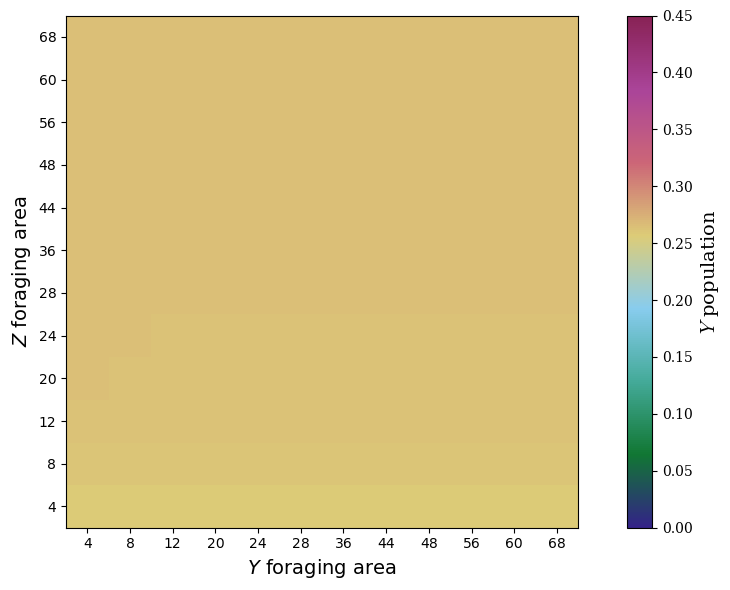

In [10]:
fig, ax = plt.subplots(figsize = (10,6))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
paleta = ['#332288','#117733','#44AA99','#88CCEE','#DDCC77','#CC6677','#AA4499','#882255']
cmap = LinearSegmentedColormap.from_list("minha_paleta", paleta)
c = ax.imshow(pop_y_cm, cmap=cmap, vmin=0, vmax=0.45, origin = 'lower')
cbar = fig.colorbar(c, ax=ax)
cbar.set_label(r"$Y$ population", fontsize=14)
posicoes = np.arange(len(raios))
plt.xticks(ticks=posicoes, labels=raios)
plt.yticks(ticks=posicoes, labels=raios)
plt.xlabel(r"$Y$ foraging area",fontsize=14)
plt.ylabel(r"$Z$ foraging area",fontsize=14)
plt.tight_layout()
#plt.savefig("colormap_cm.png", dpi = 300)
plt.show()

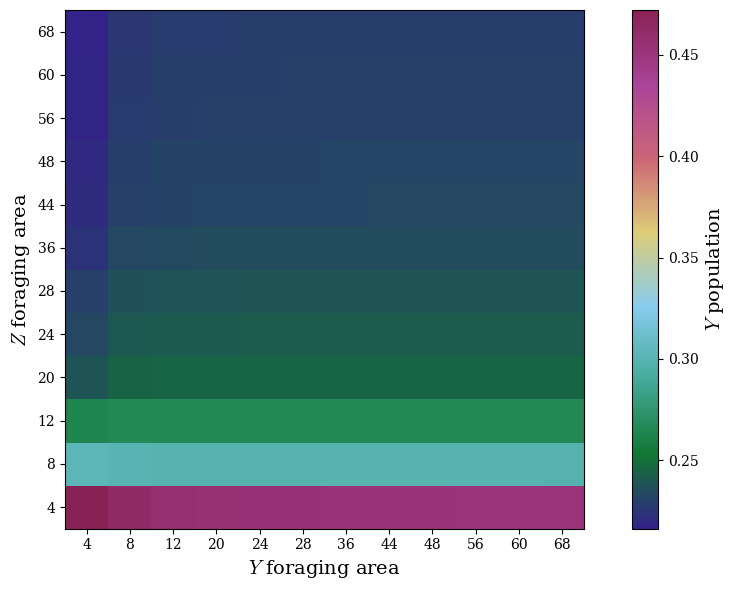

In [11]:
fig, ax = plt.subplots(figsize = (10,6))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
paleta = ['#332288','#117733','#44AA99','#88CCEE','#DDCC77','#CC6677','#AA4499','#882255']
cmap = LinearSegmentedColormap.from_list("minha_paleta", paleta)
c = ax.imshow(pop_y_par, cmap=cmap, interpolation = None,origin = 'lower')
cbar = fig.colorbar(c, ax=ax)
cbar.set_label(r"$Y$ population", fontsize=14)
posicoes = np.arange(len(raios))
plt.xticks(ticks=posicoes, labels=raios)
plt.yticks(ticks=posicoes, labels=raios)
plt.xlabel(r"$Y$ foraging area", fontsize=14)
plt.ylabel(r"$Z$ foraging area", fontsize=14)
plt.tight_layout()
#plt.savefig("colormap_par_y.png", dpi = 300)
plt.show()

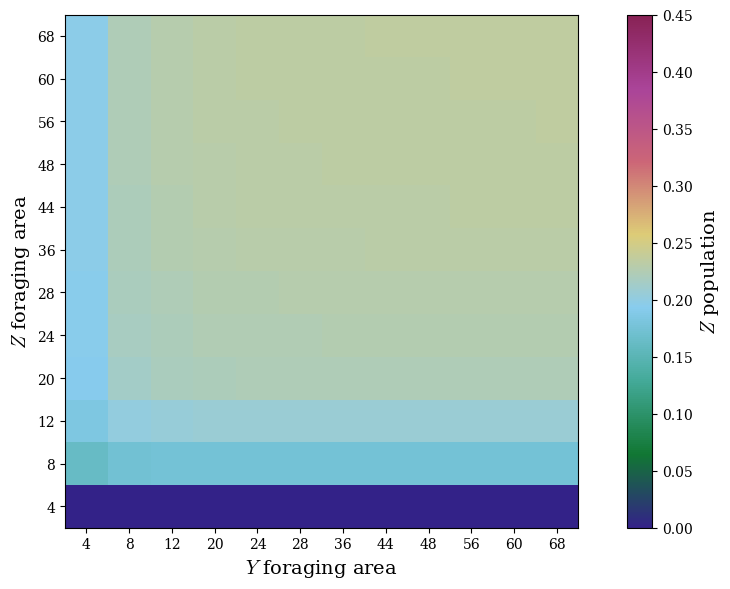

In [12]:
fig, ax = plt.subplots(figsize = (10,6))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
paleta = ['#332288','#117733','#44AA99','#88CCEE','#DDCC77','#CC6677','#AA4499','#882255']
cmap = LinearSegmentedColormap.from_list("minha_paleta", paleta)
c = ax.imshow(pop_z_par, cmap=cmap, interpolation = None,origin = 'lower', vmin=0, vmax=0.45)
cbar = fig.colorbar(c, ax=ax)
cbar.set_label(r"$Z$ population", fontsize=14)
posicoes = np.arange(len(raios))
plt.xticks(ticks=posicoes, labels=raios)
plt.yticks(ticks=posicoes, labels=raios)
plt.xlabel(r"$Y$ foraging area", fontsize=14)
plt.ylabel(r"$Z$ foraging area", fontsize=14)
plt.tight_layout()
#plt.savefig("colormap_par_z.png", dpi = 300)
plt.show()

In [13]:
ry1, rz1, valor = np.loadtxt("/home/lucas/Documents/doutorado/tres_especies_mutacao/colormap_pop/resultados prontos/pop_y.txt", unpack = True)
pop_y_sim = np.zeros((24, 24))
a = 0
for i in range(24):
    for j in range(24):
        pop_y_sim[i][j] = valor[a]
        a+=1
ry2, rz2, valor2 = np.loadtxt("/home/lucas/Documents/doutorado/tres_especies_mutacao/colormap_pop/resultados prontos/pop_z.txt", unpack = True)
pop_z_sim = np.zeros((24,24))
a = 0
for i in range(24):
    for j in range(24):
        pop_z_sim[i][j] = valor2[a]
        a+=1

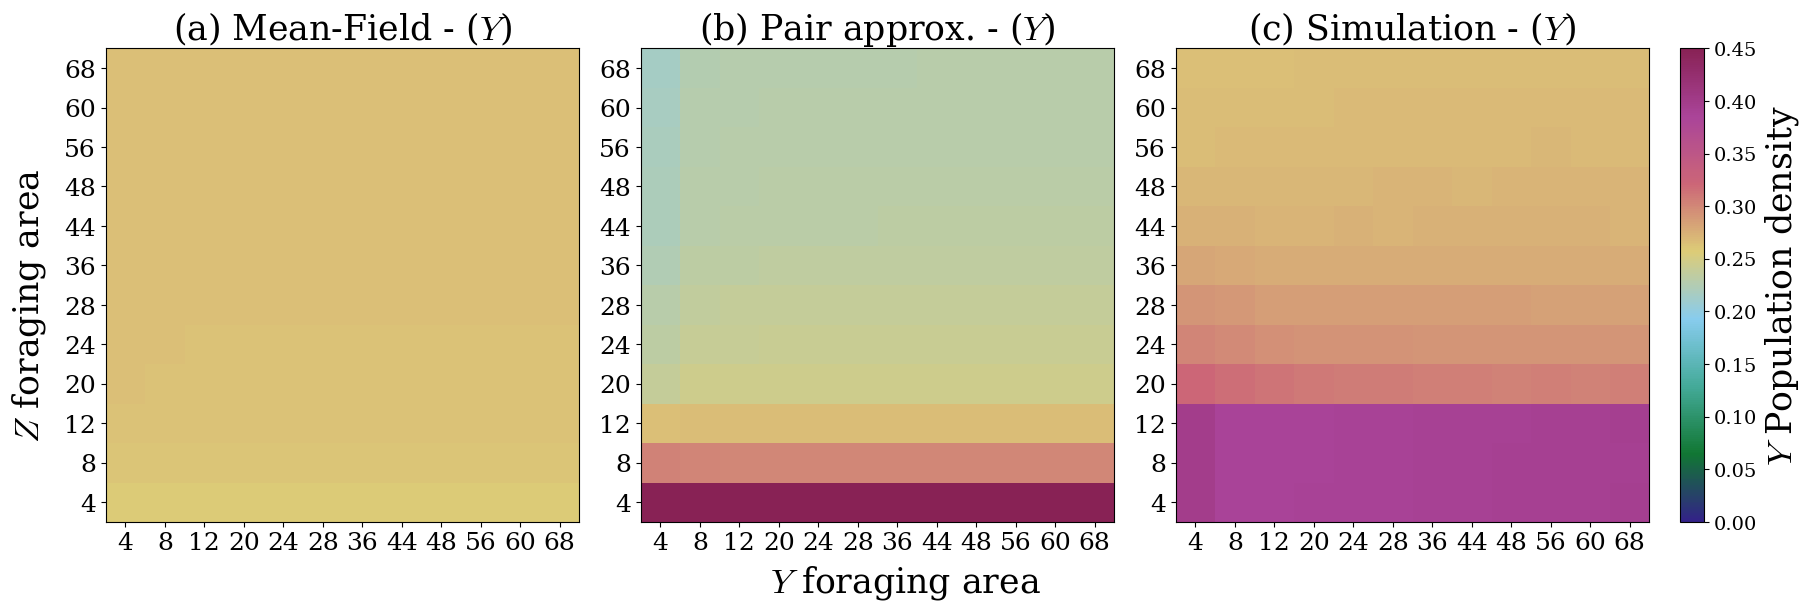

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

im = None
for ax, dado, titulo in zip(
    axs,
    [pop_y_cm, pop_y_par, pop_y_sim[:pop_y_cm.shape[0], :pop_y_cm.shape[1]]],
    [r"(a) Mean-Field - ($Y$)", r"(b) Pair approx. - ($Y$)", r"(c) Simulation - ($Y$)"]
):

    im = ax.imshow(dado, cmap=cmap, origin='lower',
                   vmin=0, vmax=0.45)

    ax.set_title(titulo, fontsize = 25)
    ax.tick_params(axis='both', labelsize=18)

    ax.set_xticks(np.arange(len(raios)))
    ax.set_xticklabels(raios)
    ax.set_yticks(np.arange(len(raios)))
    ax.set_yticklabels(raios)

# Uma única colorbar para todos os eixos
cbar = fig.colorbar(im, ax=axs, pad = 0.02)
cbar.set_label(r"$Y$ Population density", fontsize=25)
cbar.ax.tick_params(labelsize=14)
fig.supxlabel(r"$Y$ foraging area", fontsize=25)
fig.supylabel(r"$Z$ foraging area", fontsize=25)
plt.savefig("color_map_y.pdf", bbox_inches="tight")
plt.show()

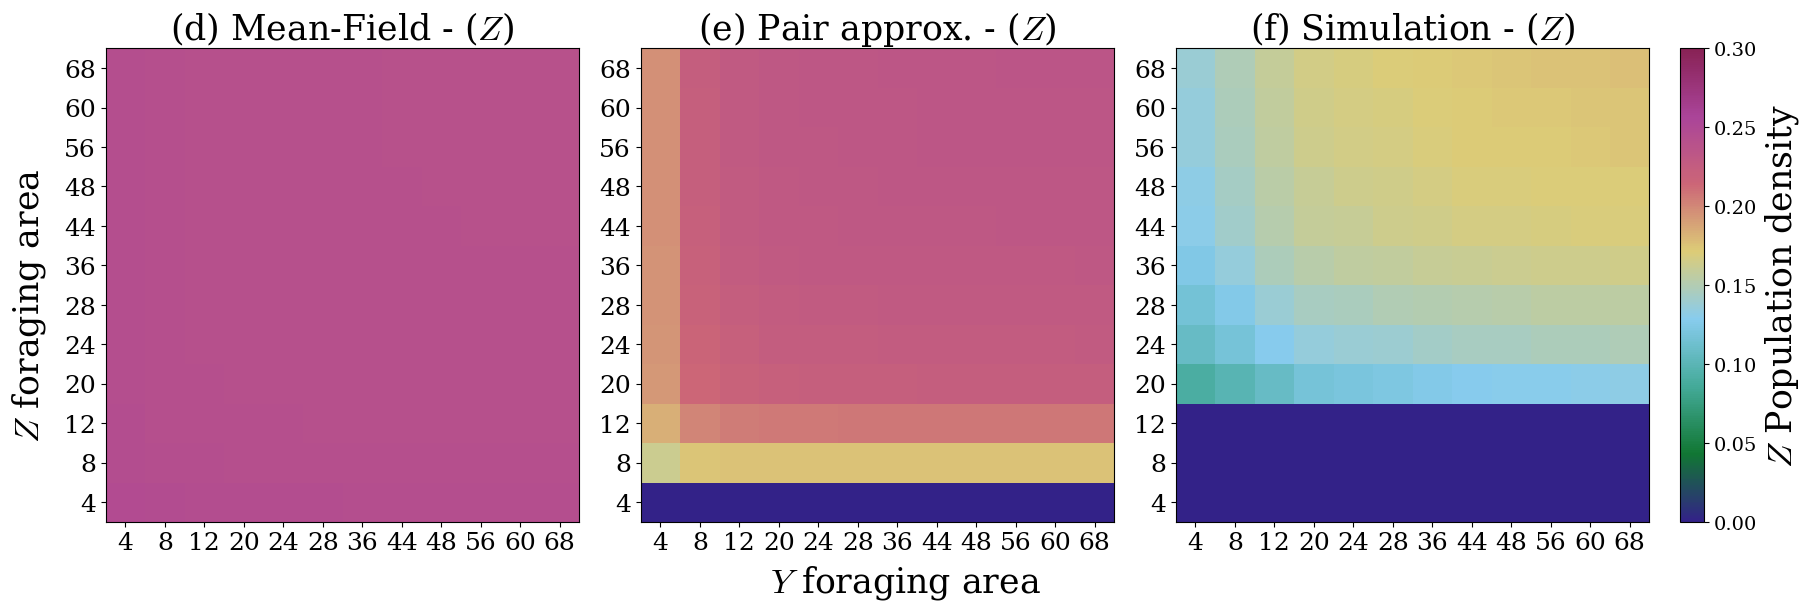

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

im = None
for ax, dado, titulo in zip(
    axs,
    [pop_z_cm, pop_z_par, pop_z_sim[:pop_z_cm.shape[0], :pop_z_cm.shape[1]]],
    [r"(d) Mean-Field - ($Z$)", r"(e) Pair approx. - ($Z$)", r"(f) Simulation - ($Z$)"]
):

    im = ax.imshow(dado, cmap=cmap, origin='lower',
                   vmin=0, vmax=0.3)

    ax.set_title(titulo, fontsize = 25)
    ax.tick_params(axis='both', labelsize=18)
    ax.set_xticks(np.arange(len(raios)))
    ax.set_xticklabels(raios)
    ax.set_yticks(np.arange(len(raios)))
    ax.set_yticklabels(raios)

# Uma única colorbar para todos os eixos
cbar = fig.colorbar(im, ax=axs, pad = 0.02)
cbar.set_label(r"$Z$ Population density", fontsize=25)
cbar.ax.tick_params(labelsize=14)
fig.supxlabel(r"$Y$ foraging area", fontsize=25)
fig.supylabel(r"$Z$ foraging area", fontsize=25)
plt.savefig("color_map_z.pdf",bbox_inches = "tight")
plt.show()